# Notebook 2: Climatology & Index Construction

This notebook analyses the seasonal climatology and long term trends of the study region, then constructs the compound Wind Hydro Drought Index (WHDI):

1. Monthly climatology and seasonal cycles
2. Long term trends for all variables
3. Standardisation of wind speed and runoff
4. WHDI construction (WHDI1, WHDI3, WHDI6)
5. Drought event cataloguing
6. Component correlation analysis

**Key question for this notebook:** Do wind and runoff anomalies co occur, justifying a compound index? If they're uncorrelated, compound droughts are random coincidences rather than a coherent phenomenon.

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv(
    "../data/processed/combined_dataset.csv", index_col="date", parse_dates=True
)

print(f"Data loaded: {df.shape}")
print(f"Period: {df.index[0]} to {df.index[-1]}")
print(f"Variables: {list(df.columns)}")
print("\nMissing Values:")
print(df.isna().sum())
print("\nFirst few rows:")
df.head()

Data loaded: (564, 8)
Period: 1979-01-01 00:00:00 to 2025-12-01 00:00:00
Variables: ['wind_speed', 'temperature', 'precipitation', 'runoff', 'snowmelt', 'sam', 'oni', 'iod']

Missing Values:
wind_speed       0
temperature      0
precipitation    0
runoff           0
snowmelt         0
sam              0
oni              0
iod              8
dtype: int64

First few rows:


,wind_speed,temperature,precipitation,runoff,snowmelt,sam,oni,iod
date,,,,,,,,
1979-01-01,3.591189,20.300608,33.127508,4.771823,0.007942,0.74,0.03,0.317
1979-02-01,4.052137,19.015506,13.530812,2.303862,0.008822,-0.90,0.07,-0.158
1979-03-01,2.668088,15.476255,31.482286,2.530781,0.201180,1.51,0.20,-0.034
1979-04-01,2.939223,12.290993,11.758993,1.787631,0.171488,-0.49,0.28,-0.207
1979-05-01,4.399244,7.483713,74.614402,12.958914,18.369194,1.54,0.23,-0.444


## Monthly Climatology

In [2]:
# Computing long term mean and standard deviation of each month
climatology = df.groupby(df.index.month).agg(["mean", "std"])

# Flatten the multi level column names
climatology.columns = [f"{var}_{stat}" for var, stat in climatology.columns]

climatology.to_csv("../results/tables/monthly_climatology.csv")

print("Monthly Climatology:")
climatology.round(3)

Monthly Climatology:


,wind_speed_mean,wind_speed_std,temperature_mean,temperature_std,precipitation_mean,precipitation_std,runoff_mean,runoff_std,snowmelt_mean,snowmelt_std,sam_mean,sam_std,oni_mean,oni_std,iod_mean,iod_std
date,,,,,,,,,,,,,,,,
1,4.313,0.897,19.291,0.946,28.048,11.665,5.633,1.702,0.393,0.384,0.940,1.700,0.045,1.074,-0.013,0.249
2,3.531,1.007,18.362,1.079,29.591,13.327,3.772,1.338,0.376,0.611,0.198,1.942,0.047,0.925,-0.032,0.232
3,3.464,0.900,15.474,0.952,37.443,13.961,4.250,1.597,0.845,0.870,0.247,1.663,0.055,0.744,-0.039,0.265
4,3.928,0.958,11.148,1.090,44.142,20.254,6.737,3.776,4.395,3.654,0.554,1.638,0.060,0.607,-0.019,0.262
5,4.053,1.002,7.325,1.088,55.093,24.262,13.327,7.656,11.872,7.465,0.320,1.510,0.063,0.557,-0.037,0.306
6,4.505,1.029,4.405,1.300,62.702,20.919,18.333,6.420,19.415,7.044,0.390,1.786,0.055,0.575,-0.046,0.346
7,4.141,1.050,3.742,1.265,53.924,21.125,16.671,6.009,17.787,7.015,0.329,1.622,0.046,0.642,-0.056,0.367
8,4.111,0.844,5.631,0.916,51.338,15.743,16.614,6.443,20.211,6.783,-0.054,1.708,0.037,0.743,-0.052,0.412
9,3.683,0.987,8.096,0.882,41.837,16.131,17.866,4.574,20.886,5.733,-0.078,1.678,0.030,0.869,-0.046,0.426


## Seasonal Cycle Plots

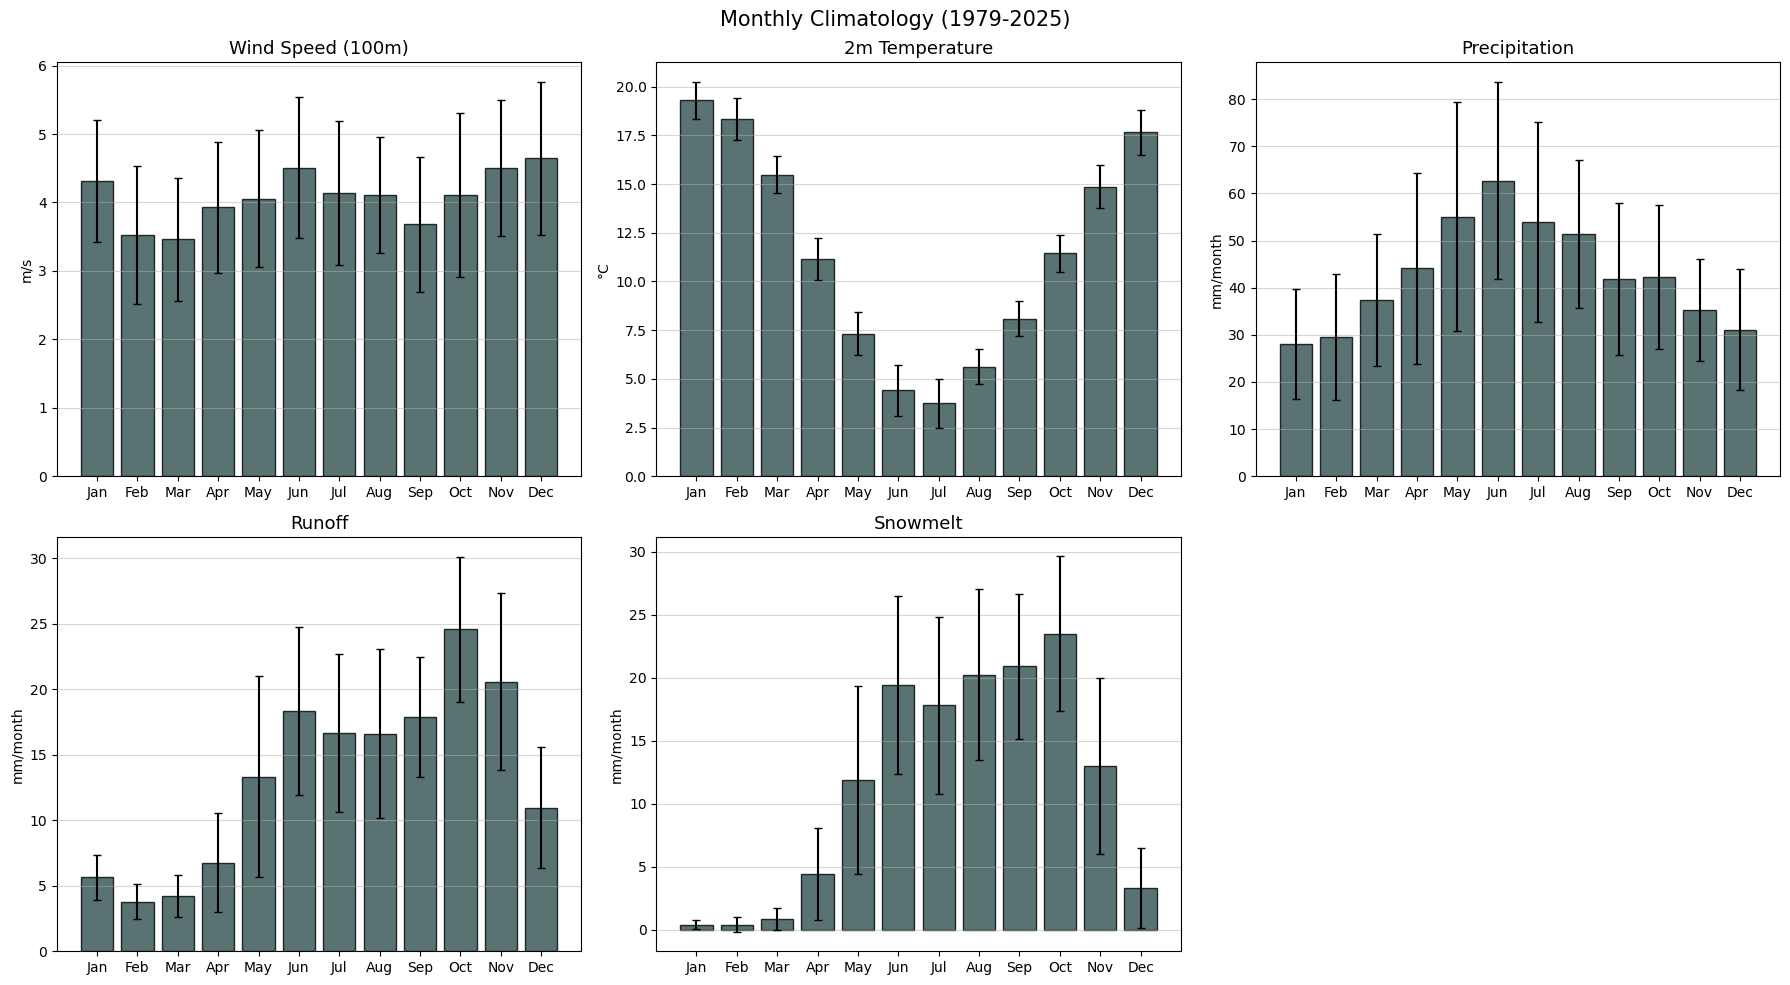

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Define the labels and variables
era5_vars = [
    ("wind_speed", "m/s", "Wind Speed (100m)"),
    ("temperature", "°C", "2m Temperature"),
    ("precipitation", "mm/month", "Precipitation"),
    ("runoff", "mm/month", "Runoff"),
    ("snowmelt", "mm/month", "Snowmelt"),
]
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# Create all the plots
for ax, (var, unit, title) in zip(axes.flat, era5_vars):
    monthly_mean = df.groupby(df.index.month)[var].mean()
    monthly_std = df.groupby(df.index.month)[var].std()

    ax.bar(
        range(1, 13),
        monthly_mean,
        yerr=monthly_std,
        capsize=3,
        color="darkslategrey",
        alpha=0.8,
        edgecolor="black",
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(unit)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.grid(True, alpha=0.5, axis="y")

# Remove the 6th plot
axes.flat[-1].set_visible(False)
plt.suptitle("Monthly Climatology (1979-2025)", fontsize=15)
plt.tight_layout()
plt.savefig("../results/figures/seasonal_cycles.png", dpi=200, bbox_inches="tight")
plt.show()

### Observations

**Wind Speed** peaks November, December, and June.   
**Temperature** peaks January, February, and December.   
**Precipitation** peaks in the summer.   
**Runoff** lags precipitation by about 3 months, and minorly lags snowmelt.   
**Snowmelt** peaks in October, September, and August.

## Long Term Trends

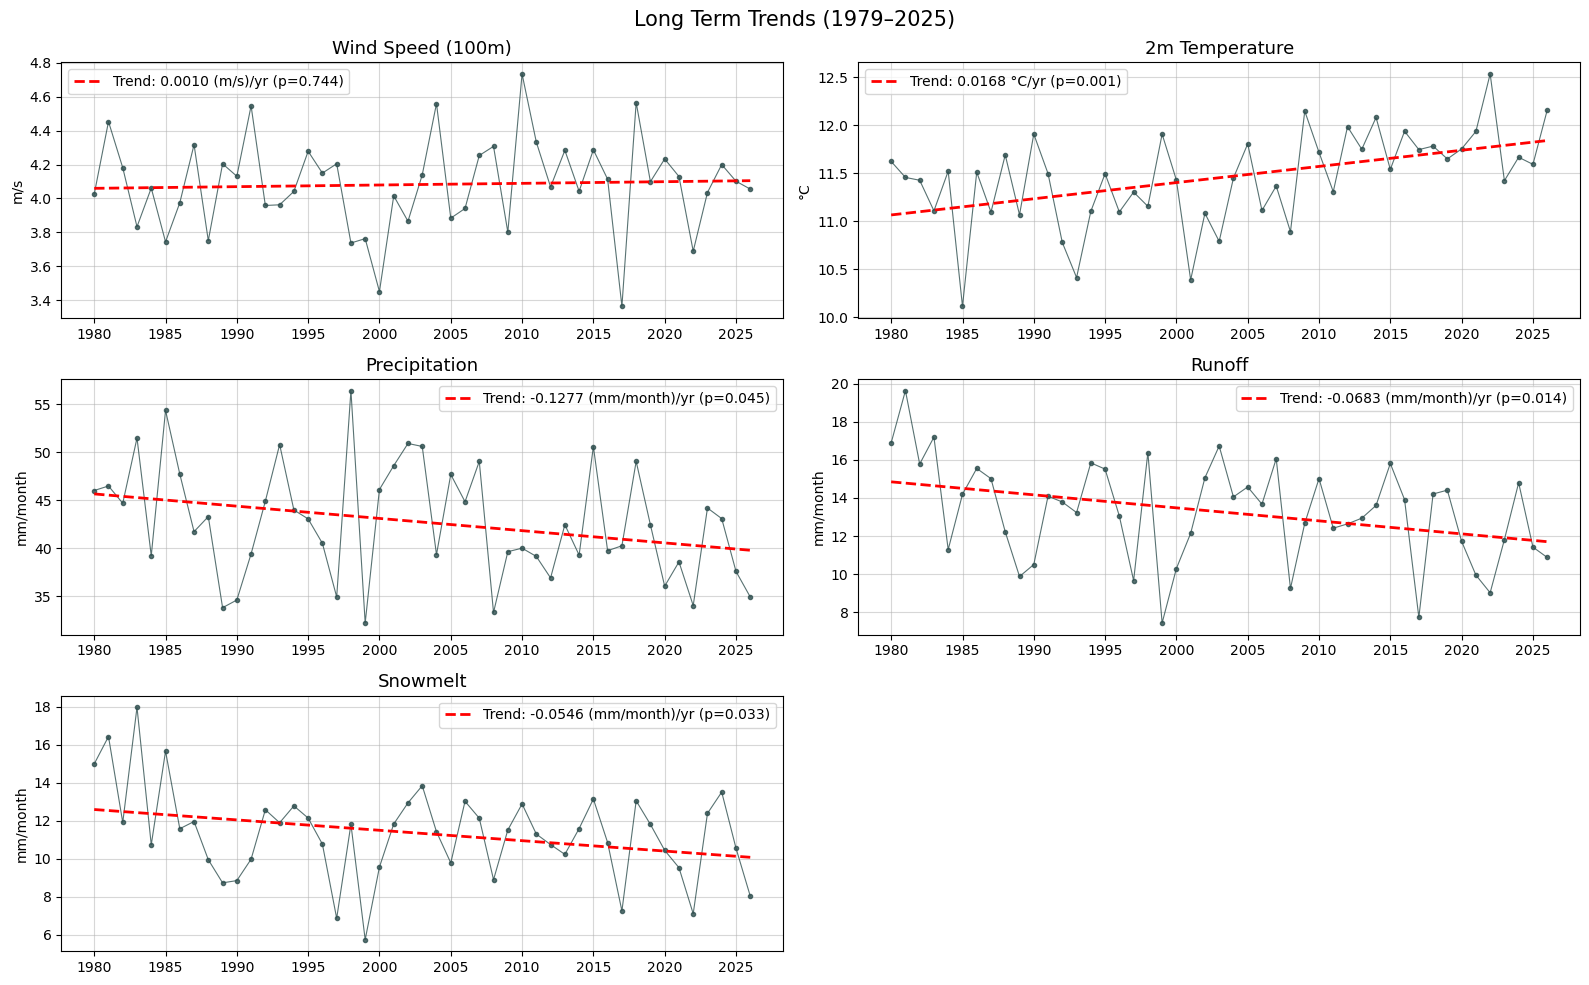

In [4]:
# Computing linear trends of each era5 variable

trend_results = {}

# Plot all the graphs, using era5_vars from previous cell
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for ax, (var, unit, title) in zip(axes.flat, era5_vars):
    # Annual means to reduce noise
    annual = df[var].resample("YE").mean()

    # Numeric x axis for regression
    x = np.arange(len(annual))
    y = annual.values

    # Just in case removing nan if the final year is missing values
    mask = ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]

    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    trend_line = (slope * x) + intercept

    total_change = slope * len(annual)

    trend_results[var] = {
        "slope_per_year": slope,
        "total_change": total_change,
        "r_squared": r_value**2,
        "p_value": p_value,
        "significant": p_value < 0.05,
    }

    # Plot
    ax.plot(
        annual.index,
        annual.values,
        "o-",
        markersize=3,
        linewidth=0.8,
        color="darkslategrey",
        alpha=0.8,
    )
    ax.plot(
        annual.index,
        trend_line[mask],
        "r--",
        linewidth=2,
        label=f"Trend: {slope:.4f} {f'({unit})' if '/' in unit else unit}/yr (p={p_value:.3f})",
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(unit)
    ax.legend()
    ax.grid(True, alpha=0.5)

axes.flat[-1].set_visible(False)
plt.suptitle("Long Term Trends (1979–2025)", fontsize=15)
plt.tight_layout()
plt.savefig("../results/figures/long_term_trends.png", dpi=200, bbox_inches="tight")
plt.show()

In [5]:
df_trends = pd.DataFrame(trend_results).T
df_trends.to_csv("../results/tables/trend_results.csv")

## Standardisation

I standardise wind speed and runoff by calendar month. For each month: anomaly = (value - monthly_mean) / monthly_std. This is to remove the seasonal cycle so that January can always be compared to any other January.

In [6]:
def standardise_by_months(series):
    """Standardise a timeseries by calendar month climatology"""
    monthly_mean = series.groupby(series.index.month).transform("mean")
    monthly_std = series.groupby(series.index.month).transform("std")
    return (series - monthly_mean) / monthly_std


df["wind_std"] = standardise_by_months(df["wind_speed"])
df["runoff_std"] = standardise_by_months(df["runoff"])

print("Verification of Standardised Wind by Month:")
print(df.groupby(df.index.month)["wind_std"].agg(["mean", "std"]).round(4))
print("\nVerification of Standardised Runoff by Month:")
print(df.groupby(df.index.month)["runoff_std"].agg(["mean", "std"]).round(4))

Verification of Standardised Wind by Month:
      mean  std
date           
1     -0.0  1.0
2      0.0  1.0
3     -0.0  1.0
4      0.0  1.0
5     -0.0  1.0
6      0.0  1.0
7     -0.0  1.0
8     -0.0  1.0
9      0.0  1.0
10     0.0  1.0
11     0.0  1.0
12    -0.0  1.0

Verification of Standardised Runoff by Month:
      mean  std
date           
1      0.0  1.0
2      0.0  1.0
3      0.0  1.0
4      0.0  1.0
5     -0.0  1.0
6     -0.0  1.0
7     -0.0  1.0
8      0.0  1.0
9      0.0  1.0
10    -0.0  1.0
11    -0.0  1.0
12    -0.0  1.0


## Consctructing Wind Hydro Drought Index

In [7]:
# Equal weighting of standardised wind and runoff anomalies
df["whdi_raw"] = (df["wind_std"] + df["runoff_std"]) / 2

# Rolling variants
df["whdi_3raw"] = df["whdi_raw"].rolling(window=3, min_periods=3).mean()
df["whdi_6raw"] = df["whdi_raw"].rolling(window=6, min_periods=6).mean()

# Re standardise the variables so thresholds are meaningful
whdi_vars = [
    ("whdi_raw", "whdi_1"),
    ("whdi_3raw", "whdi_3"),
    ("whdi_6raw", "whdi_6"),
]
for raw, final in whdi_vars:
    series = df[raw].dropna()
    df[final] = (df[raw] - series.mean()) / series.std()

df = df.drop(columns=["whdi_raw", "whdi_3raw", "whdi_6raw"])

print("WHDI Statistics:")
print(f"  WHDI1: mean={df['whdi_1'].mean():.4f}, std={df['whdi_1'].std():.4f}")
print(f"  WHDI3: mean={df['whdi_3'].mean():.4f}, std={df['whdi_3'].std():.4f}")
print(f"  WHDI6: mean={df['whdi_6'].mean():.4f}, std={df['whdi_6'].std():.4f}")
print(f"\n  WHDI1 range: {df['whdi_1'].min():.3f} to {df['whdi_1'].max():.3f}")
print(f"  WHDI3 range: {df['whdi_3'].min():.3f} to {df['whdi_3'].max():.3f}")
print(f"  WHDI6 range: {df['whdi_6'].min():.3f} to {df['whdi_6'].max():.3f}")

WHDI Statistics:
  WHDI1: mean=-0.0000, std=1.0000
  WHDI3: mean=-0.0000, std=1.0000
  WHDI6: mean=0.0000, std=1.0000

  WHDI1 range: -2.408 to 3.431
  WHDI3 range: -3.245 to 3.502
  WHDI6 range: -2.926 to 2.840


## WHDI Timeseries Plot

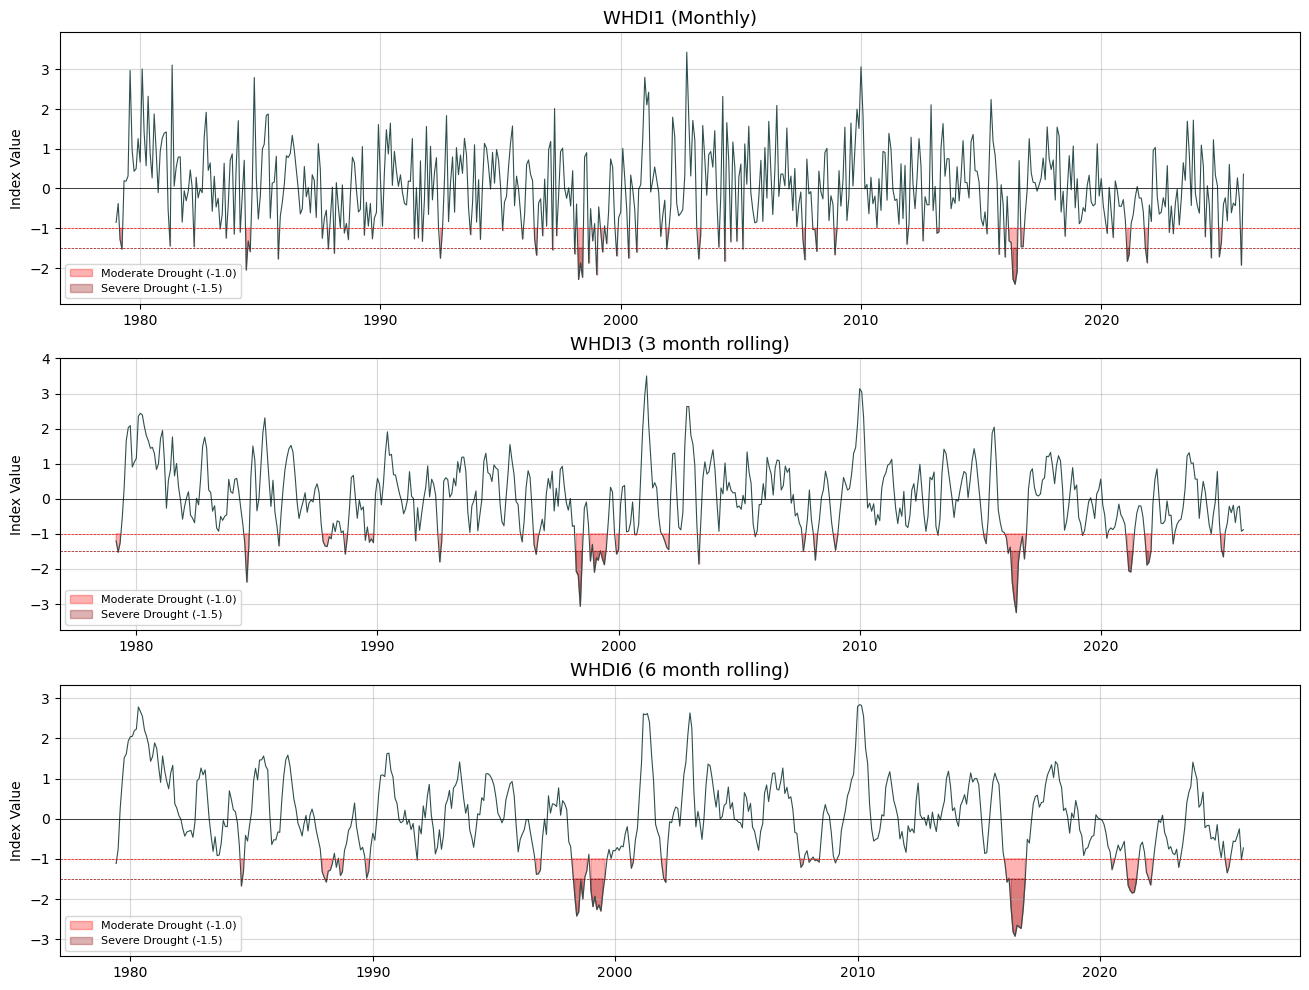

In [ ]:
from torch import layout


fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (whdi_var, title) in zip(
    axes,
    [
        ("whdi_1", "WHDI1 (Monthly)"),
        ("whdi_3", "WHDI3 (3 month rolling)"),
        ("whdi_6", "WHDI6 (6 month rolling)"),
    ],
):
    series = df[whdi_var]

    # Plot index
    ax.plot(series.index, series.values, linewidth=0.8, color="darkslategrey")

    # Fill moderate drought periods
    ax.fill_between(
        series.index,
        series.values,
        -1.0,
        where=(series.values < -1.0),
        color="red",
        alpha=0.3,
        label="Moderate Drought (-1.0)",
    )

    # Fill severe drought periods
    ax.fill_between(
        series.index,
        series.values,
        -1.5,
        where=(series.values < -1.5),
        color="darkred",
        alpha=0.3,
        label="Severe Drought (-1.5)",
    )

    # Reference Lines
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.axhline(y=-1.0, color="red", linestyle="--", linewidth=0.5)
    ax.axhline(y=-1.5, color="darkred", linestyle="--", linewidth=0.5)

    ax.set_ylabel("Index Value")
    ax.set_title(title, fontsize=13)
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, alpha=0.5)
    ax.set_ylim(df[whdi_var].min() - 0.5, df[whdi_var].max() + 0.5)

axes[-1].set_title("Year")
plt.suptitle("Wind Hydro Drought Index 1979-2025 (WHDI)", fontsize=15)
plt.tight_layout()
plt.savefig("../results/figures/whdi_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

## Drought Frequency Analysis

Split the record into two periods to compare drought frequency and then use the midpoint of the record as the split.

Midpoint: 2002

Drought Frequency where WHDI3 < -1.0
First Half Drought Percentage: 16.08%
Second Half Drought Percentage: 13.77%

Drought Frequency where WHDI3 < -1.5
First Half Drought Percentage: 5.59%
Second Half Drought Percentage: 5.43%


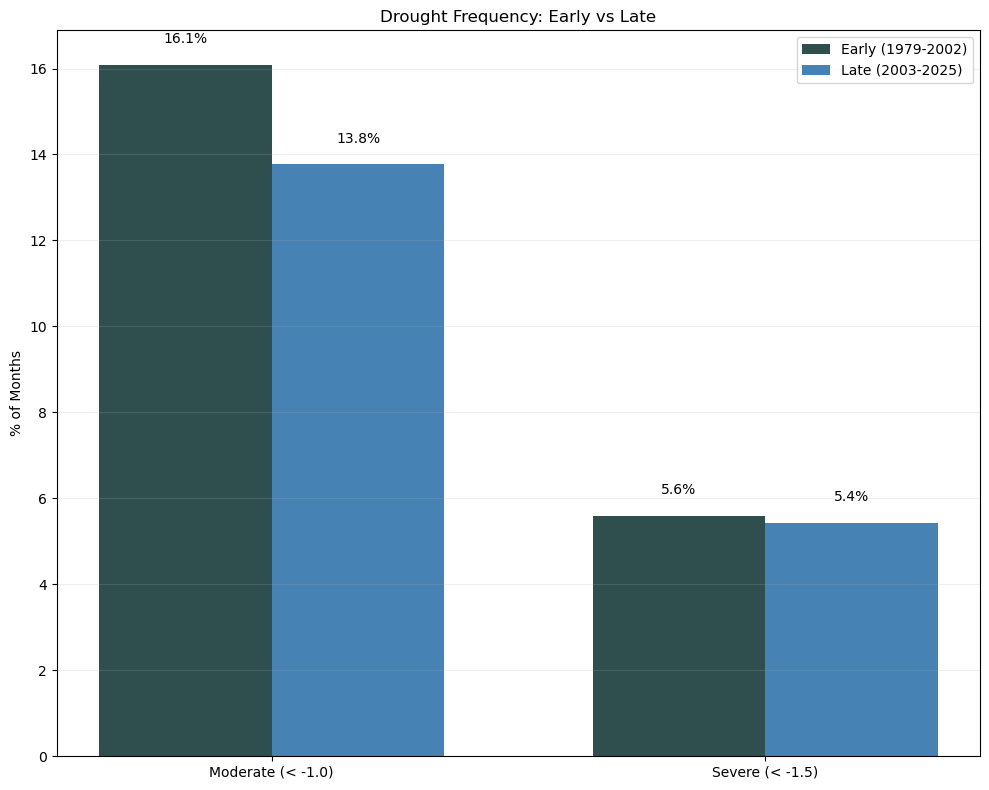

In [8]:
midpoint = df.index[0] + (df.index[-1] - df.index[0]) / 2
midpoint_year = midpoint.year
print(f"Midpoint: {midpoint_year}")

early = df.loc[:f"{midpoint_year}", "whdi_3"].dropna()
late = df.loc[f"{midpoint_year + 1}":, "whdi_3"].dropna()

# Drought frequency where months below threshold -1.0
early_drought_pct = ((early < -1.0).sum() / len(early)) * 100
late_drought_pct = ((late < -1.0).sum() / len(late)) * 100

print("\nDrought Frequency where WHDI3 < -1.0")
print(f"First Half Drought Percentage: {early_drought_pct:.2f}%")
print(f"Second Half Drought Percentage: {late_drought_pct:.2f}%")

# Drought frequency where months below threshold -1.5
early_severe_pct = ((early < -1.5).sum() / len(early)) * 100
late_severe_pct = ((late < -1.5).sum() / len(late)) * 100

print("\nDrought Frequency where WHDI3 < -1.5")
print(f"First Half Drought Percentage: {early_severe_pct:.2f}%")
print(f"Second Half Drought Percentage: {late_severe_pct:.2f}%")

# Visualise the frequency with a bar charts
fig, ax = plt.subplots(figsize=(10, 8))

x = np.arange(2)
width = 0.35

bar1 = ax.bar(
    x - width / 2,
    [early_drought_pct, early_severe_pct],
    width,
    label=f"Early ({df.index[0].year}-{midpoint_year})",
    color="darkslategrey",
)
bar2 = ax.bar(
    x + width / 2,
    [late_drought_pct, late_severe_pct],
    width,
    label=f"Late ({midpoint_year + 1}-{df.index[-1].year})",
    color="steelblue",
)

ax.set_ylabel("% of Months")
ax.set_title("Drought Frequency: Early vs Late")
ax.set_xticks(x)
ax.set_xticklabels(["Moderate (< -1.0)", "Severe (< -1.5)"])
ax.legend()
ax.grid(True, alpha=0.2, axis="y")

# Add the values onto the bars
for bar in bar1:
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=10,
    )
for bar in bar2:
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=10,
    )

plt.tight_layout()

## Component Correlation Analysis

Are wind droughts and runoff droughts happening at the same time? If they're correlated, something (possibly a shared climate driver) causes both to fail together. If uncorrelated, compound events are just coincidence.

Overall correlation (wind_std vs runoff_std): r = 0.203, p = 0.0000

Seasonal Corelations:
  DJF: r = 0.274, p = 0.0010 very significant
  MAM: r = 0.353, p = 0.0000 very significant
  JJA: r = 0.120, p = 0.1564 not significant
  SON: r = 0.064, p = 0.4543 not significant


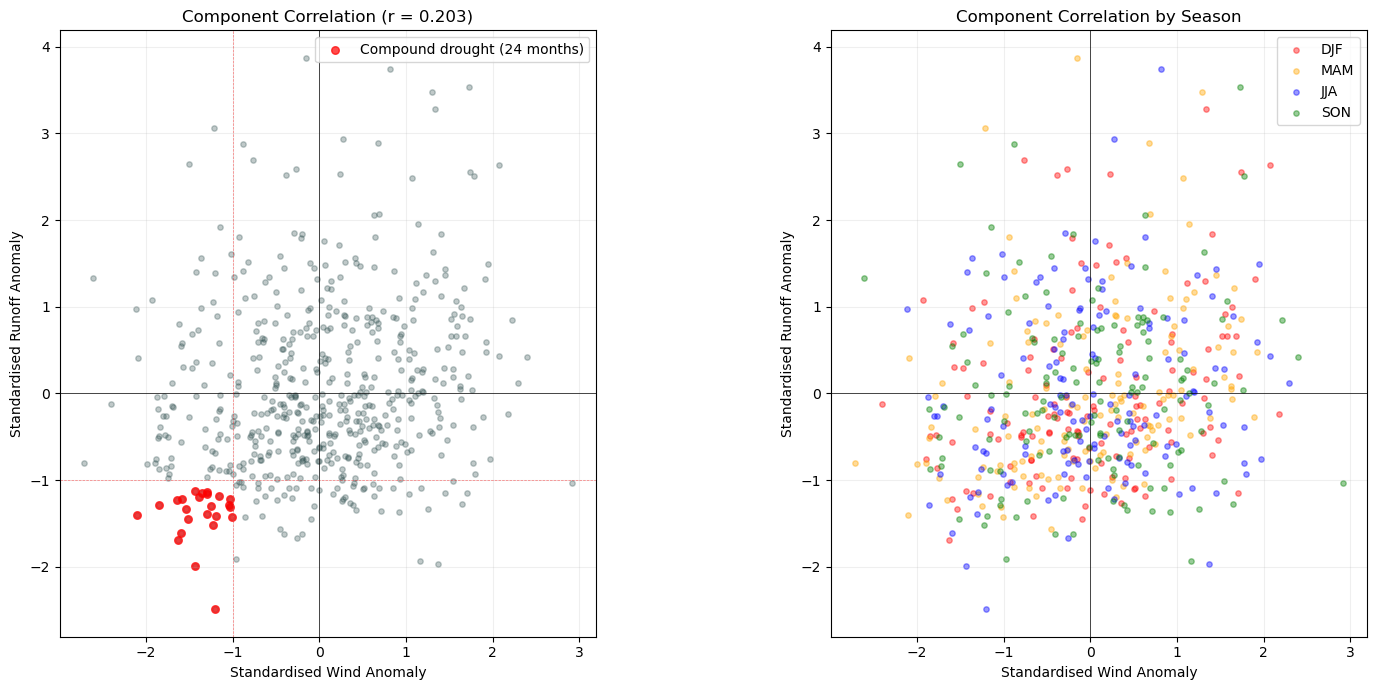

In [9]:
# Overall correlation
overall_corr, overall_p = stats.pearsonr(
    df["wind_std"].dropna(), df["runoff_std"].dropna()
)
print(
    f"Overall correlation (wind_std vs runoff_std): r = {overall_corr:.3f}, p = {overall_p:.4f}"
)

# Seasonal Correlations
print("\nSeasonal Corelations:")
season_names = {
    1: "DJF",
    2: "DJF",
    12: "DJF",
    3: "MAM",
    4: "MAM",
    5: "MAM",
    6: "JJA",
    7: "JJA",
    8: "JJA",
    9: "SON",
    10: "SON",
    11: "SON",
}
df["season"] = df.index.month.map(season_names)

for season in ["DJF", "MAM", "JJA", "SON"]:
    subset = df[df["season"] == season]
    corr, p = stats.pearsonr(subset["wind_std"].dropna(), subset["runoff_std"].dropna())
    sig = (
        "very significant"
        if p < 0.01
        else "significant" if p < 0.05 else "not significant"
    )
    print(f"  {season}: r = {corr:.3f}, p = {p:.4f} {sig}")

# Scatter plot of wind anom vs runoff anom
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(
    df["wind_std"],
    df["runoff_std"],
    alpha=0.3,
    s=15,
    color="darkslategrey",
)

# Highlight compound drought quadrant
compound_mask = (df["wind_std"] < -1) & (df["runoff_std"] < -1)
ax.scatter(
    df.loc[compound_mask, "wind_std"],
    df.loc[compound_mask, "runoff_std"],
    alpha=0.7,
    s=30,
    color="red",
    label=f"Compound drought ({compound_mask.sum()} months)",
)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.axhline(y=-1, color="red", linewidth=0.5, linestyle="--", alpha=0.5)
ax.axvline(x=-1, color="red", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xlabel("Standardised Wind Anomaly")
ax.set_ylabel("Standardised Runoff Anomaly")
ax.set_title(f"Component Correlation (r = {overall_corr:.3f})")
ax.legend()
ax.grid(True, alpha=0.2)
ax.set_aspect("equal")

ax = axes[1]
season_colors = {"DJF": "red", "MAM": "orange", "JJA": "blue", "SON": "green"}
for season, color in season_colors.items():
    subset = df[df["season"] == season]
    ax.scatter(
        subset["wind_std"],
        subset["runoff_std"],
        alpha=0.4,
        s=15,
        color=color,
        label=season,
    )

ax.axhline(y=0, color="black", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Standardised Wind Anomaly")
ax.set_ylabel("Standardised Runoff Anomaly")
ax.set_title("Component Correlation by Season")
ax.legend()
ax.grid(True, alpha=0.2)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(
    "../results/figures/component_correlation.png", dpi=200, bbox_inches="tight"
)
plt.show()

## Component Individual Drought Comparison

In [ ]:
# Comparison variables
wind_drought = df["wind_std"] < -1.0
runoff_drought = df["runoff_std"] < -1.0
both_drought = wind_drought & runoff_drought
either_drought = wind_drought | runoff_drought

total_months = len(df.dropna(subset=["wind_std", "runoff_std"]))

print("Individual vs Compound Drought Frequency:")
print(
    f"    Wind only drought:   {(wind_drought & ~runoff_drought).sum()} months ({(wind_drought & ~runoff_drought).sum() / total_months * 100:.1f}%)"
)
print(
    f"    Runoff only drought: {(runoff_drought & ~wind_drought).sum()} months ({(runoff_drought & ~wind_drought).sum() / total_months * 100:.1f}%)"
)
print(
    f"    Compound drought:    {both_drought.sum()} months ({both_drought.sum() / total_months * 100:.1f}%)"
)
print(
    f"    Either drought:      {either_drought.sum()} months ({either_drought.sum() / total_months * 100:.1f}%)"
)

# If wind and runoff were independent, expected compound frequency would be:
p_wind = wind_drought.sum() / total_months
p_runoff = runoff_drought.sum() / total_months
expected_compound = p_wind * p_runoff * total_months

print(
    f"\n    Expected compound drought (if independent): {expected_compound:.1f} months"
)
print(f"    Observed compound drought: {both_drought.sum()} months")

ratio = (
    both_drought.sum() / expected_compound if expected_compound > 0 else float("inf")
)
print(f"    Ratio observed/expected: {ratio:.2f}")
print("    (>1 means compound events are more common than random chance)")

Individual vs Compound Drought Frequency:
    Wind only drought:   73 months (12.9%)
    Runoff only drought: 53 months (9.4%)
    Compound drought:    24 months (4.3%)
    Either drought:      150 months (26.6%)

    Expected compound drought (if independent): 13.2 months
    Observed compound drought: 24 months
    Ratio observed/expected: 1.81
    (>1 means compound events are more common than random chance)


## Save all Outputs

In [12]:
# Save the updated dataframe with all derived variables
output_cols = [
    "wind_speed",
    "temperature",
    "precipitation",
    "runoff",
    "snowmelt",
    "sam",
    "oni",
    "iod",
    "wind_std",
    "runoff_std",
    "whdi_1",
    "whdi_3",
    "whdi_6",
]

df_output = df[output_cols]
df_output.to_csv("../data/processed/whdi_timeseries.csv")

## Summary

In [ ]:
print(" " * 20 + "WHDI Notebook Summary")
print("=" * 61)

print("Climatology:")
print(
    f"    Record: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}"
)
print(f"    Mean wind speed: {df['wind_speed'].mean():.2f}m/s")
print(f"    Mean temperature: {df['temperature'].mean():.1f}°C")
print(f"    Mean precipitation: {df['precipitation'].mean():.2f}mm/month")
print(f"    Mean runoff: {df['runoff'].mean():.2f}mm/month")

print("\nTrends:")
for var, results in trend_results.items():
    if results["significant"]:
        print(f"    {var}: {results['slope_per_year']:+.4f}/yr (significant)")

print("\nDrought Events (WHDI3 < -1.0):")
# Going to make a drought catalog

                    WHDI Notebook Summary
Climatology:
    Record: 1979-01 to 2025-12
    Mean wind speed: 4.08m/s
    Mean temperature: 11.5°C
    Mean precipitation: 42.73mm/month
    Mean runoff: 13.27mm/month

Trends:
    temperature: +0.0168/yr (significant)
    precipitation: -0.1277/yr (significant)
    runoff: -0.0683/yr (significant)
    snowmelt: -0.0546/yr (significant)
